In [ ]:
import matplotlib.pyplot as plt
from datasets import load_dataset

# --- Загрузка ---
dataset = load_dataset(
    "iamtarun/python_code_instructions_18k_alpaca", split="train"
)
df = dataset.to_pandas()

print("Колонки:", df.columns.tolist())
print("Размер:", df.shape)
print("\nПервый пример:")
print(df.iloc[0].to_dict())

Колонки: ['instruction', 'input', 'output', 'prompt']
Размер: (18612, 4)

Первый пример:
{'instruction': 'Create a function to calculate the sum of a sequence of integers.', 'input': '[1, 2, 3, 4, 5]', 'output': '# Python code\ndef sum_sequence(sequence):\n  sum = 0\n  for num in sequence:\n    sum += num\n  return sum', 'prompt': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nCreate a function to calculate the sum of a sequence of integers.\n\n### Input:\n[1, 2, 3, 4, 5]\n\n### Output:\n# Python code\ndef sum_sequence(sequence):\n  sum = 0\n  for num in sequence:\n    sum += num\n  return sum'}


In [ ]:
for i in [0, 1, 2, 100, 500]:
    print(f"\n{'=' * 60}")
    print(f"[{i}] INSTRUCTION:", df.iloc[i]["instruction"])
    print(f"[{i}] INPUT:", df.iloc[i]["input"])
    print(f"[{i}] OUTPUT (первые 300 симв.):", df.iloc[i]["output"][:300])


[0] INSTRUCTION: Create a function to calculate the sum of a sequence of integers.
[0] INPUT: [1, 2, 3, 4, 5]
[0] OUTPUT (первые 300 симв.): # Python code
def sum_sequence(sequence):
  sum = 0
  for num in sequence:
    sum += num
  return sum

[1] INSTRUCTION: Generate a Python code for crawling a website for a specific type of data.
[1] INPUT: website: www.example.com 
data to crawl: phone numbers
[1] OUTPUT (первые 300 симв.): import requests
import re

def crawl_website_for_phone_numbers(website):
    response = requests.get(website)
    phone_numbers = re.findall('\d{3}-\d{3}-\d{4}', response.text)
    return phone_numbers
    
if __name__ == '__main__':
    print(crawl_website_for_phone_numbers('www.example.com'))

[2] INSTRUCTION: Create a Python list comprehension to get the squared values of a list [1, 2, 3, 5, 8, 13].
[2] INPUT: 
[2] OUTPUT (первые 300 симв.): [x*x for x in [1, 2, 3, 5, 8, 13]]

[100] INSTRUCTION: Read a given list of strings and create a new list of all str

In [ ]:
df["output_len"] = df["output"].str.len()
df["instruction_len"] = df["instruction"].str.len()
df["total_len"] = df["output_len"] + df["instruction_len"]

print(df[["output_len", "instruction_len", "total_len"]].describe())

         output_len  instruction_len     total_len
count  18612.000000     18612.000000  18612.000000
mean     465.976306        98.189018    564.165323
std     1112.515015       109.796379   1172.345363
min        1.000000        21.000000     40.000000
25%      149.000000        68.000000    233.000000
50%      260.000000        83.000000    349.000000
75%      444.000000       103.000000    541.000000
max    20779.000000      7755.000000  21284.000000


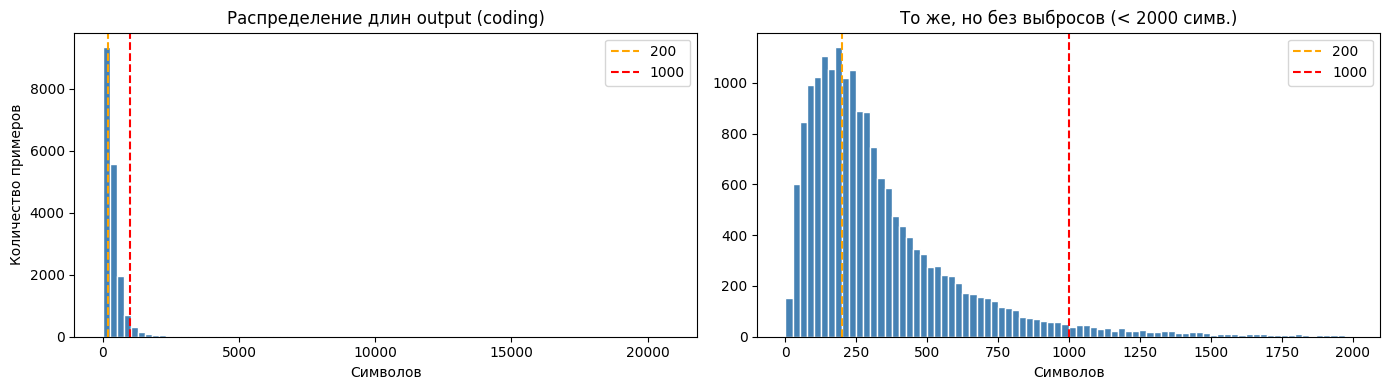

In [7]:
# --- Распределение длин output ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["output_len"], bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("Распределение длин output (coding)")
axes[0].set_xlabel("Символов")
axes[0].set_ylabel("Количество примеров")
axes[0].axvline(200, color="orange", linestyle="--", label="200")
axes[0].axvline(1000, color="red", linestyle="--", label="1000")
axes[0].legend()

# Зум на диапазон 0-2000 чтобы не тянули выбросы
df_zoom = df[df["output_len"] < 2000]
axes[1].hist(
    df_zoom["output_len"], bins=80, color="steelblue", edgecolor="white"
)
axes[1].set_title("То же, но без выбросов (< 2000 симв.)")
axes[1].set_xlabel("Символов")
axes[1].axvline(200, color="orange", linestyle="--", label="200")
axes[1].axvline(1000, color="red", linestyle="--", label="1000")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- Сравнение с нашими Q&A парами ---
import json

import pandas as pd

with open(
    "/home/danil-pc/fine-tuning_project/data/generated/qa_pairs_ru.json",
    encoding="utf-8",
) as f:
    qa_pairs = json.load(f)

qa_df = pd.DataFrame(qa_pairs)
qa_df["answer_len"] = qa_df["answer"].str.len()
qa_df["question_len"] = qa_df["question"].str.len()
qa_df["total_len"] = qa_df["answer_len"] + qa_df["question_len"]

print("Q&A из базы знаний:")
print(qa_df[["answer_len", "question_len", "total_len"]].describe())
print()
print("Coding датасет (output):")
print(df[["output_len", "instruction_len", "total_len"]].describe())

Q&A из базы знаний:
        answer_len  question_len    total_len
count   860.000000    860.000000   860.000000
mean    788.123256    106.503488   894.626744
std     113.025433     36.866638   125.614296
min     511.000000     21.000000   579.000000
25%     709.000000     78.750000   808.750000
50%     776.000000    102.000000   880.000000
75%     857.000000    131.000000   968.250000
max    1262.000000    252.000000  1386.000000

Coding датасет (output):
         output_len  instruction_len     total_len
count  18612.000000     18612.000000  18612.000000
mean     465.976306        98.189018    564.165323
std     1112.515015       109.796379   1172.345363
min        1.000000        21.000000     40.000000
25%      149.000000        68.000000    233.000000
50%      260.000000        83.000000    349.000000
75%      444.000000       103.000000    541.000000
max    20779.000000      7755.000000  21284.000000


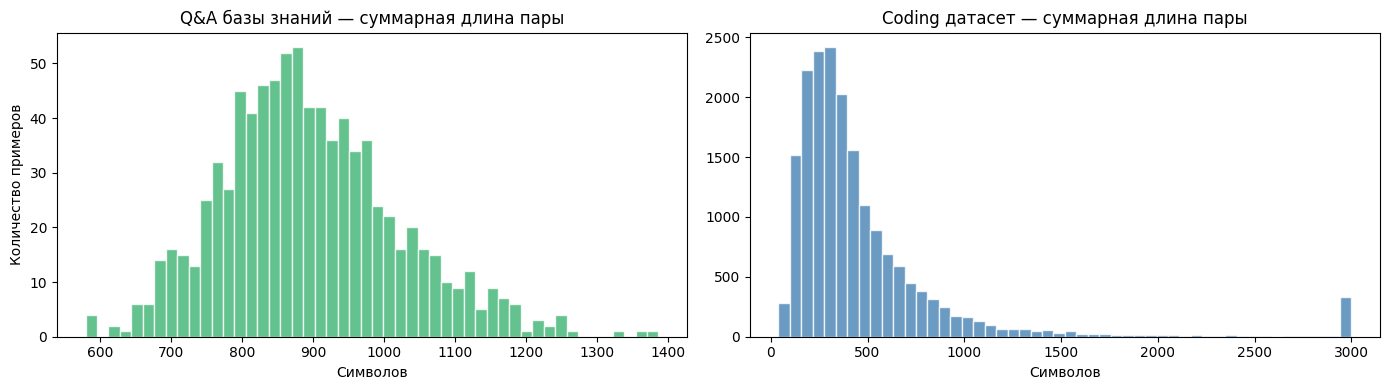

In [15]:
# --- Сравнительный график ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(
    qa_df["total_len"],
    bins=50,
    color="mediumseagreen",
    edgecolor="white",
    alpha=0.8,
)
axes[0].set_title("Q&A базы знаний — суммарная длина пары")
axes[0].set_xlabel("Символов")
axes[0].set_ylabel("Количество примеров")

axes[1].hist(
    df["total_len"].clip(upper=3000),
    bins=50,
    color="steelblue",
    edgecolor="white",
    alpha=0.8,
)
axes[1].set_title("Coding датасет — суммарная длина пары")
axes[1].set_xlabel("Символов")

plt.tight_layout()
plt.show()

In [ ]:
# --- Посмотреть что фильтруется при разных порогах ---
thresholds = [500, 800, 1000, 1500, 2000]
print("Фильтрация по output_len:\n")
print(f"{'Порог':<10} {'Осталось':<12} {'% от всего':<12}")
print("-" * 35)
for t in thresholds:
    filtered = df[df["output_len"] > 100]  # минимум
    filtered = filtered[filtered["output_len"] < t]  # максимум
    print(f"< {t:<8} {len(filtered):<12} {len(filtered) / len(df) * 100:.1f}%")

Фильтрация по output_len:

Порог      Осталось     % от всего  
-----------------------------------
< 500      12105        65.0%
< 800      14375        77.2%
< 1000     14924        80.2%
< 1500     15454        83.0%
< 2000     15603        83.8%


In [25]:
# --- Несколько примеров из разных диапазонов длин ---
print("=== КОРОТКИЕ (output < 300 симв.) ===")
short = df[df["output_len"] < 300].sample(3)
for _, row in short.iterrows():
    print(f"\nINSTRUCTION: {row['instruction']}")
    print(f"OUTPUT: {row['output']}\n")

=== КОРОТКИЕ (output < 300 симв.) ===

INSTRUCTION: Write a python code that takes in a list of integers and removes all the duplicate elements from it.
OUTPUT: final_list = [] 
for num in list_of_integers: 
    if num not in final_list: 
    	final_list.append(num) 
print(final_list)


INSTRUCTION: Using the provided Python code, optimize the code to be as efficient as possible.
OUTPUT: x = 0
y = 0

def func():
global x, y
x, y = x+1, y+2

func()
x += 9999
y += 19998


INSTRUCTION: Produce a Python code for finding the largest element in an array.
OUTPUT: def find_max(arr):
    max = arr[0]
    for i in range(1,len(arr)):
        if arr[i] > max:
            max = arr[i]
    return max

result = find_max([40, 50, 11, 70, 39])
print(result)



In [29]:
print("\n=== СРЕДНИЕ (300-800 симв.) ===")
medium = df[(df["output_len"] >= 300) & (df["output_len"] < 800)].sample(3)
for _, row in medium.iterrows():
    print(f"\nINSTRUCTION: {row['instruction']}")
    print(f"OUTPUT: {row['output'][:400]}...\n")


=== СРЕДНИЕ (300-800 симв.) ===

INSTRUCTION: Build a Python program that generates a list of prime numbers between a given range.
OUTPUT: # Function to generate prime numbers between the given range 
def generatePrimes(start, end):
    primeList = []

    for num in range(start, end + 1): 
        # all prime numbers are greater than 1
        if num > 1: 
            for i in range(2, num): 
                if (num % i) == 0: 
                    break   
            else: 
                primeList.append(num)

    return primeLis...


INSTRUCTION: Generate a Python program to find the longest common prefix string amongst an array of strings
OUTPUT: def longestCommonPrefix(strs): 
    if len(strs) == 0: 
        return "" 
  
    common_prefix = strs[0] 
  
    for i in range(1, len(strs)): 
        j = 0
        match = False
  
        # compare the current string 
        # with the previous string 
        while j < len(common_prefix) and j < len(strs[i]): 
            if commo

In [32]:
print("\n=== ДЛИННЫЕ (> 1500 симв.) ===")
long = df[df["output_len"] > 1500].sample(3)
for _, row in long.iterrows():
    print(f"\nINSTRUCTION: {row['instruction']}")
    print(f"OUTPUT (первые 400): {row['output'][:400]}...\n")


=== ДЛИННЫЕ (> 1500 симв.) ===

INSTRUCTION: This code performs BLAST evaluation. To use it, follow these steps:

1. Import the necessary libraries: glob, sys, csv, and tabulate from Bio.Blast.Applications.
2. Define the following functions:
   - carga_csv(file_name): creates a list of lists with a csv file.
   - crea_comparacion(tabla_ref, estructura = 'star', comparacion = 'bi'): creates comparisons lists (code) depending on arguments.
   - imprime_comparacion(listas): prints the comparison as a readable format.
   - imprime_referencia(claves): prints the comparison as a readable format.
   - crea_diccionario(tabla): creates a dictionary of code:organism.
3. In the program body, prompt the user to enter the CSV file name and load the data using carga_csv().
4. Present the CSV data using tabulate().
5. Present the options: blast parameters, comparison parameters, run.
6. If the user selects option 1, prompt them to enter the comparisons using the organism index and the direction (bid

In [33]:
# Смотрим сколько примеров в каждом бакете

bins = [(260, 500), (500, 800), (800, 1100), (1100, 1386)]
df_filtered = df[(df["output_len"] >= 260) & (df["output_len"] <= 1386)]

print("Примеров в каждом бакете после фильтрации:")
for lo, hi in bins:
    count = len(
        df_filtered[
            (df_filtered["output_len"] >= lo)
            & (df_filtered["output_len"] < hi)
        ]
    )
    print(f"  {lo}–{hi} символов: {count}")

Примеров в каждом бакете после фильтрации:
  260–500 символов: 5392
  500–800 символов: 2270
  800–1100 символов: 721
  1100–1386 символов: 284


In [4]:
import json
from difflib import SequenceMatcher

with open(
    "/home/danil-pc/fine-tuning_project/data/generated/qa_pairs_ru.json",
    encoding="utf-8",
) as f:
    qa_pairs = json.load(f)

threshold = 0.85
unique = []
accepted_questions = []
removed = []

for pair in qa_pairs:
    q = pair["question"].lower()

    best_match = None
    best_ratio = 0
    for existing_q, existing_pair in zip(accepted_questions, unique):
        ratio = SequenceMatcher(None, q, existing_q).ratio()
        if ratio > best_ratio:
            best_ratio = ratio
            best_match = existing_pair

    if best_ratio > threshold:
        removed.append(
            {
                "removed": pair["question"],
                "kept": best_match["question"],
                "ratio": round(best_ratio, 3),
                "source": pair.get("source_file", "?"),
            }
        )
    else:
        unique.append(pair)
        accepted_questions.append(q)

print(f"Удалено {len(removed)} пар:\n")
for r in removed:
    print(f"  УДАЛЁН   (score={r['ratio']}): {r['removed']}")
    print(f"  ПОХОЖ НА:                      {r['kept']}")
    print(f"  Источник: {r['source']}")
    print()

Удалено 3 пар:

  УДАЛЁН   (score=0.937): Как работает механизм предсказания в архитектуре EAGLE?
  ПОХОЖ НА:                      Как работает механизм предсказания в архитектуре Medusa?
  Источник: ?

  УДАЛЁН   (score=0.893): В чём разница между использованием Encoder-only модели (BERT) и Decoder-only модели (GPT) для решения задачи классификации текста без предварительного дообучения?
  ПОХОЖ НА:                      В чём разница между использованием готовой encoder-only модели (BERT) и decoder-only модели (GPT) для задачи классификации текста без дообучения?
  Источник: ?

  УДАЛЁН   (score=0.879): Что такое RMSNorm и чем он отличается от классической LayerNorm?
  ПОХОЖ НА:                      Что такое RMSNorm и чем она отличается от LayerNorm?
  Источник: ?



Мне не понравилось, что скрипт удалил из выборки Q&A пару про EAGLE, так как она не похожу по смыслу с парой про MEDUSA, поэтому я хочу вернуть ее обратно, с удалением 2-ой и 3-ей пары я согласегн. Ниже будет код для добавления пары про EAGLE в обучающую выборку

In [ ]:
import json

# Пара которую хотим добавить
eagle_pair = {
    "messages": [
        {
            "role": "system",
            "content": "Ты — технический ассистент, специализирующийся на архитектуре больших языковых моделей. Отвечай точно и развёрнуто на русском языке.",
        },
        {
            "role": "user",
            "content": "Как работает механизм предсказания в архитектуре EAGLE?",
        },
        {
            "role": "assistant",
            "content": "Механизм EAGLE основан на авторегрессии на уровне векторов скрытого состояния. На вход его единственного трансформерного слоя подается текущий feature vector от целевой модели, объединенный с эмбеддингом последнего сгенерированного токена. Слой EAGLE обрабатывает эту информацию и предсказывает, каким будет feature vector на следующем шаге генерации. Затем этот предсказанный вектор передается напрямую в LM Head (последний линейный слой) целевой модели, который преобразует его в логиты и, соответственно, в конкретный токен. Важно, что для предсказания следующего вектора EAGLE использует свой собственный предыдущий предсказанный вектор, а не токен, полученный из него, что позволяет избежать потери информации.",
        },
    ]
}

# Добавляем в train (можно заменить на val.jsonl если хочешь)
path = "/home/danil-pc/fine-tuning_project/data/final/train.jsonl"

with open(path, "a", encoding="utf-8") as f:
    f.write(json.dumps(eagle_pair, ensure_ascii=False) + "\n")

print("Пара добавлена в", path)

Пара добавлена в /home/danil-pc/fine-tuning_project/data/final/train.jsonl


#### Выборочно чекаю данные из тренировочной выборки 

In [ ]:
print(
    'Create a Python program to encode a string with a Caesar cipher.\n\nplaintext = "Caesar Cipher"\nshift = 3'
)
print("----------------------------------------------------------------------")
print(
    'def caesar_cipher(plaintext,shift):\n    ciphertext = ""\n    for char in plaintext: \n        if char == \' \':\n            ciphertext += char\n        elif  char.isupper():\n            ciphertext += chr((ord(char) + shift - 65) % 26 + 65)\n        else:\n            ciphertext += chr((ord(char) + shift - 97) % 26 + 97)\n    return ciphertext\n\nplaintext = "Caesar Cipher"\nshift = 3\nciphertext = caesar_cipher(plaintext,shift)\n\nprint("Plain Text : {}".format(plaintext))\nprint("Cipher Text : {}".format(ciphertext))'
)

Create a Python program to encode a string with a Caesar cipher.

plaintext = "Caesar Cipher"
shift = 3
----------------------------------------------------------------------
def caesar_cipher(plaintext,shift):
    ciphertext = ""
    for char in plaintext: 
        if char == ' ':
            ciphertext += char
        elif  char.isupper():
            ciphertext += chr((ord(char) + shift - 65) % 26 + 65)
        else:
            ciphertext += chr((ord(char) + shift - 97) % 26 + 97)
    return ciphertext

plaintext = "Caesar Cipher"
shift = 3
ciphertext = caesar_cipher(plaintext,shift)

print("Plain Text : {}".format(plaintext))
print("Cipher Text : {}".format(ciphertext))


In [ ]:
print(
    "Design a database in Python that stores user information.\n\nUser details should include user name (string), age (integer), address (string)."
)
print("---------------------------------------------------------------------")
print(
    'class User:\n    def __init__(self, name, age, address):\n        self.name = name\n        self.age = age\n        self.address = address\n    \n    def __str__(self):\n        return "Name: "+ self.name + ", Age: "+ str(self.age) +", Address: "+ self.address\n\nclass UsersDB:\n    def __init__(self):\n        self.users = []\n    \n    def add_user(self, user):\n        self.users.append(user)\n    \n    def get_users(self):\n        return self.users\n\n# Create a database\nusers_db = UsersDB()\n\n# Add some users\nuser1 = User("John Doe", 25, "1600 Pennsylvania Avenue NW, Washington, DC")\nusers_db.add_user(user1)\nuser2 = User("Jane Doe", 20, "22 Jump Street, New York, NY")\nusers_db.add_user(user2)\n\n# Print the users\nprint(users_db.get_users())'
)

Design a database in Python that stores user information.

User details should include user name (string), age (integer), address (string).
---------------------------------------------------------------------
class User:
    def __init__(self, name, age, address):
        self.name = name
        self.age = age
        self.address = address
    
    def __str__(self):
        return "Name: "+ self.name + ", Age: "+ str(self.age) +", Address: "+ self.address

class UsersDB:
    def __init__(self):
        self.users = []
    
    def add_user(self, user):
        self.users.append(user)
    
    def get_users(self):
        return self.users

# Create a database
users_db = UsersDB()

# Add some users
user1 = User("John Doe", 25, "1600 Pennsylvania Avenue NW, Washington, DC")
users_db.add_user(user1)
user2 = User("Jane Doe", 20, "22 Jump Street, New York, NY")
users_db.add_user(user2)

# Print the users
print(users_db.get_users())


In [ ]:
print(
    "Как работает Rolling Buffer KV Cache и для чего он используется совместно со Sliding-Window Attention?"
)
print("----------------------------------------------------------------------")
print(
    "Rolling Buffer KV Cache — это метод оптимизации памяти, при котором для хранения ключей (Keys) и значений (Values) используется буфер фиксированного размера. Он работает по принципу циклического буфера: когда приходит новый токен, он записывается на место самого старого токена в буфере. Индекс для записи вычисляется как остаток от деления текущей логической позиции токена на размер буфера (current_pos % cache_size). Совместно со Sliding-Window Attention он используется потому, что SWA определяет логическое ограничение: модель не обращает внимания на токены вне окна. Следовательно, хранить их в кеше нет необходимости. Rolling Buffer является физической реализацией этого ограничения, позволяя хранить ровно W последних токенов и экономя память видеокарты."
)

Как работает Rolling Buffer KV Cache и для чего он используется совместно со Sliding-Window Attention?
----------------------------------------------------------------------
Rolling Buffer KV Cache — это метод оптимизации памяти, при котором для хранения ключей (Keys) и значений (Values) используется буфер фиксированного размера. Он работает по принципу циклического буфера: когда приходит новый токен, он записывается на место самого старого токена в буфере. Индекс для записи вычисляется как остаток от деления текущей логической позиции токена на размер буфера (current_pos % cache_size). Совместно со Sliding-Window Attention он используется потому, что SWA определяет логическое ограничение: модель не обращает внимания на токены вне окна. Следовательно, хранить их в кеше нет необходимости. Rolling Buffer является физической реализацией этого ограничения, позволяя хранить ровно W последних токенов и экономя память видеокарты.


In [ ]:
print(
    "Generate a python program to sort an array using Merge sort method.\n\narr = [6, 5, 3, 1, 8, 7, 2, 4]"
)
print("----------------------------------------------------------------------")
print(
    '# Sort the array using Merge sort\ndef mergeSort(arr): \n    if len(arr) > 1: \n        mid = len(arr)//2 \n        L = arr[:mid] \n        R = arr[mid:] \n  \n        # Sort the left and right side\n        mergeSort(L) \n        mergeSort(R) \n  \n        # Merge the parts recursively \n        i = j = k = 0\n        \n        while i < len(L) and j < len(R): \n            if L[i] < R[j]: \n                arr[k] = L[i] \n                i+=1\n            else: \n                arr[k] = R[j] \n                j+=1\n            k+=1\n          \n        # Checking if any element was left \n        while i < len(L): \n            arr[k] = L[i] \n            i+=1\n            k+=1\n          \n        while j < len(R): \n            arr[k] = R[j] \n            j+=1\n            k+=1\n  \n# Print the sorted array\nmergeSort(arr) \nprint("Sorted array is:",arr)'
)

Generate a python program to sort an array using Merge sort method.

arr = [6, 5, 3, 1, 8, 7, 2, 4]
----------------------------------------------------------------------
# Sort the array using Merge sort
def mergeSort(arr): 
    if len(arr) > 1: 
        mid = len(arr)//2 
        L = arr[:mid] 
        R = arr[mid:] 
  
        # Sort the left and right side
        mergeSort(L) 
        mergeSort(R) 
  
        # Merge the parts recursively 
        i = j = k = 0
        
        while i < len(L) and j < len(R): 
            if L[i] < R[j]: 
                arr[k] = L[i] 
                i+=1
            else: 
                arr[k] = R[j] 
                j+=1
            k+=1
          
        # Checking if any element was left 
        while i < len(L): 
            arr[k] = L[i] 
            i+=1
            k+=1
          
        while j < len(R): 
            arr[k] = R[j] 
            j+=1
            k+=1
  
# Print the sorted array
mergeSort(arr) 
print("Sorted array is: